---
#### **라이브러리 import 및 데이터 로드**
- Pandas, Numpy 라이브러리 import
- 수정주가, 시가총액 데이터 불러오기

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [20]:
# CEI 팩터용: 수정주가, 시가총액(ME)만 로드 (경로: input/)
adj_close_df = pd.read_csv("../../00_input/KOSPI_KOSDAQ_adj_close.csv", index_col="Date", parse_dates=True)
mkt_cap_df   = pd.read_csv("../../00_input/KOSPI_KOSDAQ_mkt_cap.csv", index_col="Date", parse_dates=True)
# sector_df    = pd.read_csv("../input/KOSPI_KOSDAQ_sector.csv", index_col="Date", parse_dates=True)
factors      = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)

In [21]:
# 전처리 함수 정의
def make_ff_factors(factors, annual_rf=True):
    """
    factors: DataFrame with columns ['KOSPI','SMB','HML','MOM','RF']
    """
    
    df = factors.copy()

    # 0. resampling
    df = df.resample('ME').last()
    
    # 1. 지수 → 수익률 변환
    ret_cols = ['KOSPI','SMB','HML','MOM']
    df[ret_cols] = df[ret_cols].pct_change()
    
    # 2. 무위험금리 변환 (연율 → 일/월 수익률)
    df['RF'] = df['RF'] / 100  # % → 소수화 (예: 3.5% → 0.035)
    df['RF'] = (1 + df['RF']) ** (1/12) - 1
    
    # 4. 컬럼 정리
    df = df[['KOSPI','SMB','HML','MOM','RF']].dropna()
    
    return df

In [22]:
factors_monthly = make_ff_factors(factors)[:-1]

---
#### **초기 작업 및 설정**
- 금융 섹터 제외
- 월 수익률 데이터 생성
- CEI 팩터 생성
- 리밸런싱 기준일 리스트 생성
- 포트폴리오 수익률을 저장할 객체 생성

In [23]:
# 1) 월 데이터 생성
ret_m = adj_close_df.resample('ME').last().pct_change(fill_method = None)

In [24]:
# 3) 백테스트 기간을 설정하여 월말 날짜 리스트 생성
month_ends  = adj_close_df.resample('ME').last().loc['1999-12-31':'2026-02-28'].index # 방법 1 : resample 함수를 사용하여 월말 날짜 생성

# 4) 포트폴리오 수익률을 저장할 Series 객체 생성
portfolio_returns                = pd.Series(dtype=float)
portfolio_returns[month_ends[0]] = 0.0

---
#### **CEI 팩터 데이터프레임 생성**
- 모든 월말(month_end)에 대해 각 종목의 CEI 계산
- 5년 lookback: CEI_i,t = log(ME_i,t / ME_i,t-5) − log(P_i,t / P_i,t-5)
- 수정주가·시가총액 기반, decile/rank 없이 CEI 값만 저장

In [25]:
# 월말 수정주가, 월말 시가총액
price_m    = adj_close_df.resample('ME').last()
mkt_cap_m  = mkt_cap_df.resample('ME').last()

# 5년 = 60개월 lookback
MONTHS_5Y = 60

# CEI_i,t = log(ME_i,t / ME_i,t-5) − log(P_i,t / P_i,t-5)
#        = log(ME_t) - log(ME_t_5) - log(P_t) + log(P_t_5)
log_ME_t   = np.log(mkt_cap_m.replace(0, np.nan))
log_ME_t_5 = np.log(mkt_cap_m.shift(MONTHS_5Y).replace(0, np.nan))
log_P_t    = np.log(price_m.replace(0, np.nan))
log_P_t_5  = np.log(price_m.shift(MONTHS_5Y).replace(0, np.nan))

cei_df = (log_ME_t - log_ME_t_5) - (log_P_t - log_P_t_5)

# 유효한 시점만 사용: 5년 전 데이터가 있는 월말부터
cei_df = cei_df.loc[cei_df.index[MONTHS_5Y]:]

# 결과: index=월말 날짜, columns=종목, values=CEI
# cei_df

---
#### **포트폴리오 수익률 계산**
- 리밸런싱: 매 월말 형성일(rebal_start)에 CEI 기준 종목 선정 → 다음 월말(rebal_end)까지 보유
- 코스피/코스닥 금융업 제외: sector 기준 '금융', '증권', '보험' 포함 종목 제외
- 전략: 저 CEI(주식 발행 적음) 종목 동일가중 롱

In [26]:
# 저 CEI 비중 (하위 20%, 최소 10종목)
PCT_LOW_CEI = 0.20
MIN_STOCKS = 10

for i in range(0, len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]

    # 유니버스에서 CEI 존재 종목만
    cei_t = cei_df.loc[rebal_start].dropna()

    n_select = max(MIN_STOCKS, int(len(cei_t) * PCT_LOW_CEI))
    # n_select = 20
    selected = cei_t.nsmallest(n_select).index

    # 다음 달 수익률로 동일가중 수익률 계산
    period_ret = ret_m.loc[rebal_end, ret_m.columns.intersection(selected)].dropna()
    portfolio_returns.loc[rebal_end] = period_ret.mean()

portfolio_returns

1999-12-31    0.000000
2000-01-31   -0.017555
2000-02-29   -0.001045
2000-03-31    0.149476
2000-04-30   -0.121955
                ...   
2025-10-31    0.014537
2025-11-30    0.004932
2025-12-31    0.027215
2026-01-31    0.092331
2026-02-28    0.073835
Length: 315, dtype: float64

In [27]:
# 1) 포트폴리오 NAV 계산
nav = (1 + portfolio_returns.fillna(0)).cumprod()
nav

1999-12-31     1.000000
2000-01-31     0.982445
2000-02-29     0.981418
2000-03-31     1.128117
2000-04-30     0.990537
                ...    
2025-10-31    49.589655
2025-11-30    49.834247
2025-12-31    51.190503
2026-01-31    55.916995
2026-02-28    60.045624
Length: 315, dtype: float64

<Axes: >

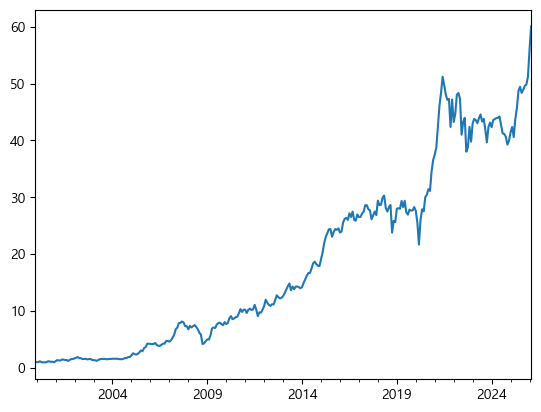

In [28]:
nav.plot()

In [29]:
# 무위험 수익률 (연 2%)
rf_annual = 0.02
rf_monthly = (1 + rf_annual) ** (1/12) - 1

# 수익률 시리즈 (월별, NaN 제외)
returns = portfolio_returns.dropna()

# 1) CAGR
start_val = 1.0
end_val = nav.iloc[-1] / nav.iloc[0]   # 이미 초기값 1이면 nav.iloc[-1]만 써도 됨
years = (nav.index[-1] - nav.index[0]).days / 365.25
cagr = (end_val ** (1 / years)) - 1 if years > 0 else 0

# 2) 연환산 변동성 (월 수익률 × sqrt(12))
volatility = returns.std() * np.sqrt(12)

# 3) Sharpe Ratio (연환산 기준, 무위험 2%)
monthly_excess = returns.mean() - rf_monthly
monthly_vol = returns.std()
monthly_sharpe = (monthly_excess / monthly_vol) if monthly_vol > 0 else np.nan
sharpe_ratio = monthly_sharpe * np.sqrt(12) if monthly_vol > 0 else np.nan

# 4) MDD (Maximum Drawdown)
# 누적 최고점 대비 현재 NAV가 얼마나 떨어졌는지
cummax = nav.cummax()
drawdown = (nav - cummax) / cummax   # 구간별 drawdown (0 ~ -1 사이)
mdd = drawdown.min()                 # MDD = drawdown의 최솟값 (음수)

# CAGR 계산
print(f"CAGR: {cagr:.2%}")
# 연 환산 변동성 계산
print(f"Annualized Volatility: {volatility:.2%}")
# Sharpe Ratio 계산
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
# MDD 출력 (예: -15.3% 형태로)
print(f"Maximum Drawdown: {mdd:.2%}")


CAGR: 16.94%
Annualized Volatility: 21.87%
Sharpe Ratio: 0.74
Maximum Drawdown: -48.95%


In [ ]:
# 코스피 지수 데이터 불러오기
ks200_df = pd.read_csv('../../00_input/KOSPI_index.csv', index_col='Date', parse_dates=True)

<Axes: >

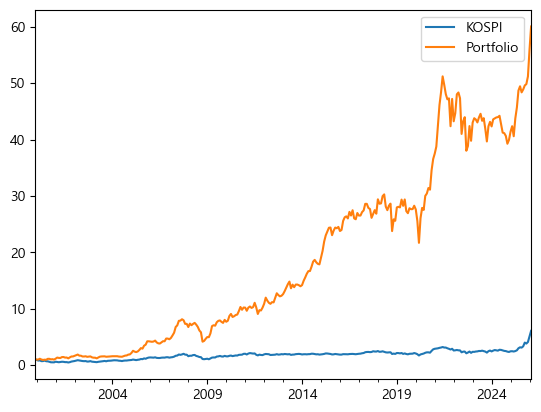

In [33]:
# 1) 월말 데이터로 리샘플링
ks200_montly = ks200_df.resample('ME').last()

# 2) 포트폴리오 데이터와 Index 맞추기
ks200_montly = ks200_montly.loc[nav.index]

# 3) 포트폴리오 NAV와 초기값 통일
ks200_montly = (ks200_montly / ks200_montly.iloc[0]) * nav.iloc[0]

# 4) 코스피200와 포트폴리오 데이터 병합
ks200_montly['Portfolio'] = nav

# 5) 포트폴리오 NAV와 코스피200 시각화
ks200_montly.plot()

In [35]:
import statsmodels.api as sm

# 팩터 데이터 불러오기
factors = factors_monthly

# 포트폴리오 수익률을 DataFrame으로 변환
portfolio_df = portfolio_returns.to_frame(name='Return')

# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([portfolio_df, factors], axis=1, join="inner").dropna()

In [36]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     332.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.06e-110
Time:                        02:52:05   Log-Likelihood:                 730.91
No. Observations:                 315   AIC:                            -1452.
Df Residuals:                     310   BIC:                            -1433.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0060      0.001      5.278      0.0

---
#### **매년 3월 리밸런싱 포트폴리오 수익률**
- 형성일: 매년 3월 말 → 보유: 당해 4월 ~ 익년 3월 말 (12개월)
- 금융 제외·저 CEI 동일가중 선정 방식은 동일, 리밸런싱만 연 1회(3월)로 적용

In [12]:
# 3) 백테스트 기간을 설정하여 3월 말 날짜 리스트 생성
from pandas.tseries.offsets import YearEnd

year_ends = pd.date_range(start='1999-12-31', end='2023-12-31', freq=YearEnd(month=3)).tolist()

# 4) 포트폴리오 수익률을 저장할 Series 객체 생성
portfolio_returns_march = pd.Series(index=year_ends, dtype=float)
portfolio_returns_march[year_ends[0]] = 0.0

In [13]:
# 매년 3월 말만 리밸런싱일로 사용 (ret_m 월수익률로 구간 수익률 계산)
for i in range(0, len(year_ends) - 1):
    rebal_start = year_ends[i]      # ① 3월 말 형성일 (포트폴리오 구성 시점)
    rebal_end   = year_ends[i + 1]  # ② 익년 3월 말 (보유 종료일, 수익률 실현 시점)

    # ③ 해당 형성일 유니버스에서 CEI 하위 20% 종목 선정 (최소 10종목)
    n_select = max(MIN_STOCKS, int(len(cei_t) * PCT_LOW_CEI))
    selected = cei_t.nsmallest(n_select).index

    # ④ rebal_start 다음 달 ~ rebal_end 달까지의 월별 인덱스 범위
    start_idx = month_ends.get_loc(rebal_start) + 1   # 형성일 다음 달부터
    end_idx   = month_ends.get_loc(rebal_end) + 1     # 보유 종료월까지(포함)
    if end_idx > len(month_ends):
        continue

    # ⑤ 구간 내 매월 동일가중 수익률 수집 (ret_m 사용)
    period_rets = []
    for j in range(start_idx, end_idx):
        m = month_ends[j]
        r = ret_m.loc[m, ret_m.columns.intersection(selected)].dropna()
        period_rets.append(r.mean() if not r.empty else np.nan)

    # ⑥ 전부 NaN이면 스킵; NaN 월은 0으로 간주 후 기하누적
    if np.all(np.isnan(period_rets)):
        continue
    period_rets = np.where(np.isnan(period_rets), 0, period_rets)
    cumret = np.prod(np.array(period_rets) + 1) - 1   # (1+r1)*...*(1+rT) - 1

    # ⑦ 해당 연도(보유 종료일) 연수익률 저장
    portfolio_returns_march.loc[rebal_end] = cumret

portfolio_returns_march

2000-03-31    0.000000
2001-03-31   -0.201237
2002-03-31    0.576725
2003-03-31   -0.429767
2004-03-31    0.417912
2005-03-31    0.365704
2006-03-31    0.693350
2007-03-31    0.226437
2008-03-31    0.201081
2009-03-31   -0.198315
2010-03-31    0.584480
2011-03-31    0.136448
2012-03-31    0.138439
2013-03-31    0.163180
2014-03-31    0.115465
2015-03-31    0.283569
2016-03-31    0.154527
2017-03-31    0.045257
2018-03-31    0.063311
2019-03-31   -0.035451
2020-03-31   -0.221442
2021-03-31    0.970383
2022-03-31    0.117933
2023-03-31   -0.113450
dtype: float64

In [14]:
# 1) 포트폴리오 NAV 계산
nav_march = (1 + portfolio_returns_march.fillna(0)).cumprod()
nav_march

2000-03-31     1.000000
2001-03-31     0.798763
2002-03-31     1.259429
2003-03-31     0.718168
2004-03-31     1.018298
2005-03-31     1.390694
2006-03-31     2.354931
2007-03-31     2.888175
2008-03-31     3.468931
2009-03-31     2.780988
2010-03-31     4.406420
2011-03-31     5.007669
2012-03-31     5.700924
2013-03-31     6.631201
2014-03-31     7.396876
2015-03-31     9.494401
2016-03-31    10.961542
2017-03-31    11.457629
2018-03-31    12.183019
2019-03-31    11.751117
2020-03-31     9.148923
2021-03-31    18.026884
2022-03-31    20.152843
2023-03-31    17.866498
dtype: float64

<Axes: >

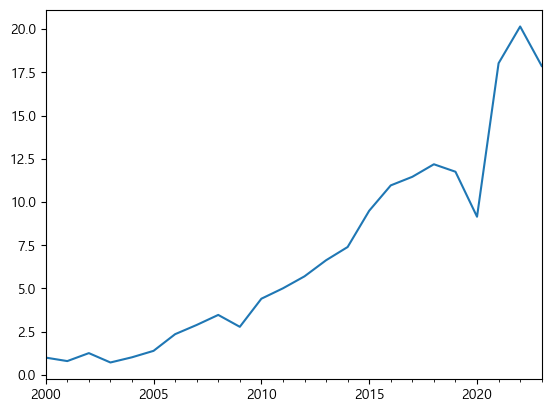

In [15]:
nav_march.plot()

In [16]:
# 무위험 수익률 (연 2%)
rf_annual = 0.02
# 수익률 시리즈 (월별, NaN 제외)
returns = portfolio_returns_march.dropna()

# 1) CAGR
start_val = 1.0
end_val = nav_march.iloc[-1] / nav_march.iloc[0]   # 이미 초기값 1이면 nav.iloc[-1]만 써도 됨
years = (nav_march.index[-1] - nav_march.index[0]).days / 365.25
cagr = (end_val ** (1 / years)) - 1 if years > 0 else 0

# 2) 연 변동성
volatility = returns.std()

# 3) Sharpe Ratio (연환산 기준, 무위험 2%)
excess_return = returns.mean() - rf_annual
sharpe_ratio = (excess_return / volatility) if volatility > 0 else np.nan

# CAGR 계산
print(f"CAGR: {cagr:.2%}")
# 연 환산 변동성 계산
print(f"Annualized Volatility: {volatility:.2%}")
# Sharpe Ratio 계산
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

CAGR: 13.36%
Annualized Volatility: 31.91%
Sharpe Ratio: 0.47


In [17]:
# 3) 백테스트 기간을 설정하여 월말 날짜 리스트 생성
month_ends  = adj_close_df.resample('ME').last().loc['1999-12-31':'2025-12-31'].index # 방법 1 : resample 함수를 사용하여 월말 날짜 생성

# 4) 포트폴리오 수익률을 저장할 Series 객체 생성
portfolio_returns_mcap = pd.Series(index=month_ends, dtype=float)
portfolio_returns_mcap[month_ends[0]] = 0.0

In [18]:
for i in range(0, len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]

    n_select = max(MIN_STOCKS, int(len(cei_t) * PCT_LOW_CEI))
    selected = cei_t.nsmallest(n_select).index.tolist()

    # 형성일 시점 시가총액으로 비중 계산
    cap_t = mkt_cap_m.loc[rebal_start, mkt_cap_m.columns.intersection(selected)].dropna()
    if cap_t.empty:
        continue
    weights = (cap_t / cap_t.sum()).reindex(selected).fillna(0)

    # 다음 달 수익률 (없는 종목은 제외 후 비중 재정규화)
    period_ret = ret_m.loc[rebal_end, ret_m.columns.intersection(selected)].dropna()
    if period_ret.empty:
        continue
    common = weights.index.intersection(period_ret.index)
    w = weights.loc[common] / weights.loc[common].sum()
    portfolio_returns_mcap.loc[rebal_end] = (w * period_ret.loc[common]).sum()

portfolio_returns_mcap

Date
1999-12-31    0.000000
2000-01-31   -0.105659
2000-02-29   -0.080326
2000-03-31    0.038153
2000-04-30   -0.156467
                ...   
2025-08-31   -0.020710
2025-09-30    0.098032
2025-10-31    0.182873
2025-11-30   -0.038563
2025-12-31    0.111252
Freq: ME, Length: 313, dtype: float64

In [19]:
# 1) 포트폴리오 NAV 계산
nav_mcap = (1 + portfolio_returns_mcap.fillna(0)).cumprod()
nav_mcap

Date
1999-12-31    1.000000
2000-01-31    0.894341
2000-02-29    0.822502
2000-03-31    0.853883
2000-04-30    0.720279
                ...   
2025-08-31    3.977077
2025-09-30    4.366957
2025-10-31    5.165556
2025-11-30    4.966359
2025-12-31    5.518874
Freq: ME, Length: 313, dtype: float64

<Axes: xlabel='Date'>

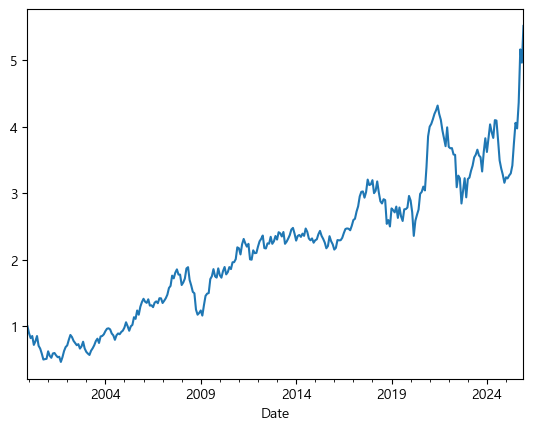

In [20]:
nav_mcap.plot()

In [21]:
# 무위험 수익률 (연 2%)
rf_annual = 0.02
rf_monthly = (1 + rf_annual) ** (1/12) - 1

# 수익률 시리즈 (월별, NaN 제외)
returns = portfolio_returns_mcap.dropna()

# 1) CAGR
start_val = 1.0
end_val = nav_mcap.iloc[-1] / nav_mcap.iloc[0]   # 이미 초기값 1이면 nav.iloc[-1]만 써도 됨
years = (nav_mcap.index[-1] - nav_mcap.index[0]).days / 365.25
cagr = (end_val ** (1 / years)) - 1 if years > 0 else 0

# 2) 연환산 변동성 (월 수익률 × sqrt(12))
volatility = returns.std() * np.sqrt(12)

# 3) Sharpe Ratio (연환산 기준, 무위험 2%)
monthly_excess = returns.mean() - rf_monthly
monthly_vol = returns.std()
monthly_sharpe = (monthly_excess / monthly_vol) if monthly_vol > 0 else np.nan
sharpe_ratio = monthly_sharpe * np.sqrt(12) if monthly_vol > 0 else np.nan

# CAGR 계산
print(f"CAGR: {cagr:.2%}")
# 연 환산 변동성 계산
print(f"Annualized Volatility: {volatility:.2%}")
# Sharpe Ratio 계산
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

CAGR: 6.79%
Annualized Volatility: 20.95%
Sharpe Ratio: 0.32


In [22]:
# --- 분위수 검증 (CEI 기준) ---
# 매 월말 CEI 10분위 → 다음 달 동일가중 수익률, 금융 제외
Q_CUT = 5
decile_cols = [f"Q({q+1}/{Q_CUT})" for q in range(Q_CUT)]
decile_ret = pd.DataFrame(index=month_ends[1:], columns=decile_cols, dtype=float)

for i in range(len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]
    try:
        quantiles = pd.qcut(cei_t, q=Q_CUT, labels=False, duplicates='drop')
    except Exception:
        continue
    for q in range(Q_CUT):
        if q not in quantiles.values:
            continue
        basket = quantiles[quantiles == q].index.tolist()
        r = ret_m.loc[rebal_end, ret_m.columns.intersection(basket)].dropna()
        if not r.empty:
            decile_ret.loc[rebal_end, decile_cols[q]] = r.mean()

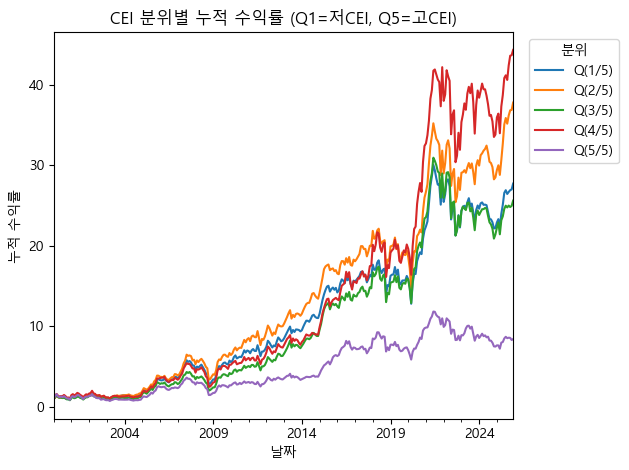

In [23]:
# 분위별 누적 수익률 (초기값 1, NaN은 0으로 간주 후 누적)
nav_decile = (1 + decile_ret.fillna(0)).cumprod()
nav_decile.plot(title='CEI 분위별 누적 수익률 (Q1=저CEI, Q5=고CEI)', xlabel='날짜', ylabel='누적 수익률')
plt.legend(title='분위', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()